# Stellar Mergers: A Binary Population Synthesis Approach

This notebook is a tutorial introducing you to binary population synthesis (BPS), binary stellar evolution, and how to run your own BPS simulations using `COMPAS`, an open source code for simulation populations of binary star systems.


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import h5py
import subprocess
import pandas as pd
from IPython.display import Image, display

pd.set_option('display.max_columns', None)

In [15]:
# increased metallicity to 0.03 (max allowed by COMPAS)

! compas_run_submit compas_test_config.yaml

python_version = 3
compas_executable_override /Users/tsdevictor/Software/COMPAS/src/COMPAS
grid_filename None
/Users/tsdevictor/Software/COMPAS/src/COMPAS --detailed-output False --number-of-systems 1000 --metallicity 0.03 --random-seed 42 --mass-transfer-fa 0.5 --common-envelope-alpha 1.0 --mode BSE --logfile-type HDF5 --output-path /Users/tsdevictor/Documents/menon-lab/stellar_mergers/tutorial

COMPAS v03.29.03 (gsl v2.8, boost v1.90.0, HDF5 v2.1.1)
Compact Object Mergers: Population Astrophysics and Statistics
by Team COMPAS (http://compas.science/index.html)
A binary star simulator

Go to https://compas.readthedocs.io/en/latest/index.html for the online documentation
Check https://compas.readthedocs.io/en/latest/pages/whats-new.html to see what's new in the latest release

Start generating binaries at Thu Apr  9 01:58:30 2026

0: Stars merged: (Main_Sequence_>_0.7 -> Early_Asymptotic_Giant_Branch) + (Main_Sequence_<=_0.7 -> Main_Sequence_<=_0.7)
1: Stars merged: (Main_Sequence_>_0.

In [19]:
output_path = 'COMPAS_Output_2/COMPAS_Output.h5'
with h5py.File(output_path, 'r') as f:
    # List all groups
    print("Data Groups: %s" % f.keys())

Data Groups: <KeysViewHDF5 ['BSE_Common_Envelopes', 'BSE_Double_Compact_Objects', 'BSE_RLOF', 'BSE_Supernovae', 'BSE_System_Parameters', 'Run_Details']>


Great! Many groups. Now let's explore a couple with this helper function. Here we can see exactly what is logged/recorded in each data group for our simulation. We will look at `BSE_System_Parameters`, which holds our initial binaries data (and some summary data on their evolution + final state), and `BSE_Common_Envelopes`, which holds the data for each CE that happens for a binary (note some binaries undergo many CE events given they survive each prior CE event).

In [20]:
def load_compas_group(h5_path, group_name):
    """
    Load a COMPAS HDF5 output group into a dictionary.
    
    Parameters:
    -----------
    h5_path : str
        Path to COMPAS_Output.h5
    group_name : str
        Name of the HDF5 group (e.g., 'BSE_System_Parameters')
    
    Returns:
    --------
    data : dict
        Dictionary mapping column names to numpy arrays
    """
    data = {}
    with h5py.File(h5_path, 'r') as f:
        group = f[group_name]
        for col in group.keys():
            data[col] = group[col][:]
    return data

sys_params_df = pd.DataFrame(load_compas_group(output_path, 'BSE_System_Parameters'))
sys_params_df.head(10)

,CH_on_MS(1),CH_on_MS(2),Eccentricity@ZAMS,Equilibrated_At_Birth,Error,Evolution_Status,Mass@ZAMS(1),Mass@ZAMS(2),Merger,Merger_At_Birth,Metallicity@ZAMS(1),Metallicity@ZAMS(2),Omega@ZAMS(1),Omega@ZAMS(2),PO_CE_Alpha,PO_CE_Formalism,PO_LBV_Factor,PO_Sigma_Kick_CCSN_BH,PO_Sigma_Kick_CCSN_NS,PO_Sigma_Kick_ECSN,PO_Sigma_Kick_USSN,PO_WR_Factor,Record_Type,SEED,SN_Kick_Magnitude_Random_Number(1),SN_Kick_Magnitude_Random_Number(2),SemiMajorAxis@ZAMS,Stellar_Type(1),Stellar_Type(2),Stellar_Type@ZAMS(1),Stellar_Type@ZAMS(2),Unbound
0,0,0,0.0,0,43,12,5.416431,0.365624,1,0,0.03,0.03,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,42,0.796543,0.950714,1.978083,5,0,1,0,0
1,0,0,0.0,0,43,12,9.884272,7.278885,1,0,0.03,0.03,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,43,0.496861,0.609067,0.179082,11,2,1,1,0
2,0,0,0.0,0,43,15,6.263390,2.504365,0,0,0.03,0.03,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,44,0.432542,0.104796,25.097195,11,11,1,1,0
3,0,0,0.0,0,43,3,8.209055,0.476427,0,0,0.03,0.03,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,45,0.304536,0.549545,39.662997,13,0,1,0,1
4,0,0,0.0,0,43,15,7.763171,3.106212,0,0,0.03,0.03,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,46,0.258047,0.634834,366.109909,12,11,1,1,0
5,0,0,0.0,0,43,12,35.560663,23.082648,1,0,0.03,0.03,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,47,0.851757,0.974483,0.950272,14,2,1,1,0
6,0,0,0.0,0,43,12,7.327586,6.346153,1,0,0.03,0.03,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,48,0.426484,0.891573,2.499422,11,2,1,1,0
7,0,0,0.0,0,43,15,5.141652,2.835602,0,0,0.03,0.03,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,49,0.473737,0.247062,49.968815,11,11,1,1,0
8,0,0,0.0,0,43,14,45.432704,18.814374,0,0,0.03,0.03,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,50,0.129175,0.228083,105.538949,14,14,1,1,0
9,0,0,0.0,0,43,3,8.613415,1.430632,0,0,0.03,0.03,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,51,0.327111,0.044712,135.193485,13,11,1,1,1


In [21]:
ce_df = pd.DataFrame(load_compas_group(output_path, 'BSE_Common_Envelopes'))
print(f"Number of CE events: {ce_df.shape[0]}")
print(f"Number of unique binary systems that had a CE event: {ce_df['SEED'].nunique()}")
ce_df.head(10)

Number of CE events: 473
Number of unique binary systems that had a CE event: 428


,BE_Fixed(1),BE_Fixed(2),BE_Kruckow(1),BE_Kruckow(2),BE_Loveridge(1),BE_Loveridge(2),BE_Loveridge_Winds(1),BE_Loveridge_Winds(2),BE_Nanjing(1),BE_Nanjing(2),Binding_Energy<CE(1),Binding_Energy<CE(2),CE_Event_Counter,Double_Core_CE,Eccentricity<CE,Eccentricity>CE,Immediate_RLOF>CE,Lambda@CE(1),Lambda@CE(2),Lambda_Convective(1),Lambda_Convective(2),Lambda_Fixed(1),Lambda_Fixed(2),Lambda_Kruckow(1),Lambda_Kruckow(2),Lambda_Loveridge(1),Lambda_Loveridge(2),Lambda_Loveridge_Winds(1),Lambda_Loveridge_Winds(2),Lambda_Nanjing(1),Lambda_Nanjing(2),Luminosity<CE(1),Luminosity<CE(2),MT_History,Mass(1)<CE,Mass(1)>CE,Mass(2)<CE,Mass(2)>CE,Mass_Convective_Env(1),Mass_Convective_Env(2),Mass_Env(1),Mass_Env(2),Merger,Optimistic_CE,RLOF(1),RLOF(2),Radius(1)<CE,Radius(1)>CE,Radius(2)<CE,Radius(2)>CE,Record_Type,RocheLobe(1)<CE,RocheLobe(1)>CE,RocheLobe(2)<CE,RocheLobe(2)>CE,SEED,SemiMajorAxis<CE,SemiMajorAxis>CE,SemiMajorAxisStage1>CE,Simultaneous_RLOF,Stellar_Type(1),Stellar_Type(1)<CE,Stellar_Type(2),Stellar_Type(2)<CE,Tau_Circ,Tau_Dynamical<CE(1),Tau_Dynamical<CE(2),Tau_Radial<CE(1),Tau_Radial<CE(2),Tau_Sync(1),Tau_Sync(2),Tau_Thermal<CE(1),Tau_Thermal<CE(2),Teff<CE(1),Teff<CE(2),Time,Zeta_Lobe,Zeta_Star
0,-8.142258e+31,1.443852e+49,-1.803887e+31,3.872335e+46,-8.142258e+30,1.443852e+48,-8.142258e+30,1.443852e+48,-8.129541e+30,1.443852e+48,3.097384e+47,1.443852e+48,1,0,0.0,0.0,0,1.001564,1.000000,0.906909,1.211386,0.1,0.1,0.451373,37.286348,1.0,1.0,1.0,1.0,1.001564,1.000000,1.010372e+04,0.018183,6,5.324550,0.000000,0.365624,0.000000,0.0,0.337923,4.050041,0.000000,1,0,1,0,263.807252,0.000000,0.351370,0.000000,1,262.349807,0.000000,80.014748,0.000000,42,432.219635,0.000000,0.0,0,5,5,0,0,0.0,9.284503e-08,1.722267e-11,0.317685,1.604761e+06,0.0,0.0,2.540411e-04,657.006019,3566.600599,3579.407232,100.418293,26.312118,0.038919
1,0.000000e+00,4.583380e+32,0.000000e+00,9.158199e+31,0.000000e+00,4.583380e+31,0.000000e+00,4.583380e+31,0.000000e+00,3.397308e+31,0.000000e+00,1.559122e+48,1,0,0.0,0.0,0,1.000000,1.349121,0.906927,0.914988,0.1,0.1,683.155082,0.500467,1.0,1.0,1.0,1.0,1.000000,1.349121,3.952919e-01,20354.483703,6,1.278502,0.000000,12.832225,0.000000,0.0,0.000000,0.000000,9.759713,1,1,0,1,0.004480,0.000000,225.957277,0.000000,1,80.393652,0.000000,225.147566,0.000000,43,389.218768,0.000000,0.0,0,11,11,2,2,0.0,1.326129e-14,4.740875e-08,-1.000000,1.159647e-02,0.0,0.0,1.326129e-14,0.000855,68446.541469,4591.233638,34.325999,17.301126,6.500000
2,0.000000e+00,-1.766407e+33,0.000000e+00,-4.966727e+32,0.000000e+00,-1.766407e+32,0.000000e+00,-1.766407e+32,0.000000e+00,-3.096603e+33,0.000000e+00,1.103572e+50,1,0,0.0,0.0,0,1.000000,0.057043,0.930066,0.946250,0.1,0.1,20590.362121,0.355648,1.0,1.0,1.0,1.0,1.000000,0.057043,1.000000e-10,314498.453229,6,6.385989,0.000000,30.438544,0.000000,0.0,0.000000,0.000000,20.555255,1,1,0,1,0.000027,0.000000,377.189175,0.000000,1,184.313482,0.000000,373.285954,0.000000,47,722.540444,0.000000,0.0,0,14,14,2,2,0.0,2.787706e-18,6.638912e-08,-1.000000,1.848979e-03,0.0,0.0,2.787706e-18,0.000166,3511.401841,7045.349722,7.726882,6.873424,6.500000
3,2.911160e+50,2.872092e+50,6.475300e+47,4.695432e+48,2.911160e+49,2.872092e+49,2.911160e+49,2.872092e+49,1.100762e+50,2.872092e+49,6.749302e+47,2.872092e+49,1,0,0.0,0.0,0,1.108152,1.000000,0.907591,0.929792,0.1,0.1,44.957908,6.116781,1.0,1.0,1.0,1.0,0.264468,1.000000,8.485647e+03,2102.445990,3,7.249738,1.426804,6.326199,6.326199,0.0,0.000000,5.822934,0.000000,0,0,1,0,214.202371,0.265388,5.288173,5.288173,1,211.535714,5.332883,198.767724,10.459968,48,541.327971,20.494968,0.0,0,7,3,1,1,0.0,5.821639e-08,2.417447e-10,0.037275,4.965002e+01,0.0,0.0,7.292637e-04,0.113028,3789.104982,17013.980428,44.011679,0.036889,-0.026331
4,0.000000e+00,5.864294e+32,0.000000e+00,2.195185e+31,0.000000e+00,5.864294e+31,0.000000e+00,5.864294e+31,0.000000e+00,7.550596e+31,0.000000e+00,9.866476e+48,2,0,0.0,0.0,0,1.000000,0.776666,0.904982,0.906911,0.1,0.1,412.278315,2.671436,1.0,1.0,1.0,1.0,1.000000,0.776666,1.5

In [22]:
# Tristan visualization

rlof_df = pd.DataFrame(load_compas_group(output_path, 'BSE_RLOF'))
print(f"Number of RLOF events: {rlof_df.shape[0]}")
print(f"Number of unique binary systems that had a RLOF event: {rlof_df['SEED'].nunique()}")
rlof_df.head(10)

Number of RLOF events: 2583
Number of unique binary systems that had a RLOF event: 544


,Beta,CEE>MT,Eccentricity<MT,Eccentricity>MT,MT_Event_Counter,Mass(1)<MT,Mass(1)>MT,Mass(2)<MT,Mass(2)>MT,MassTransferRateDonor,MassTransferTimescale,Merger,RLOF(1)<MT,RLOF(1)>MT,RLOF(2)<MT,RLOF(2)>MT,Radius(1)<MT,Radius(1)>MT,Radius(1)|RL<step,Radius(1)|RL>step,Radius(2)<MT,Radius(2)>MT,Radius(2)|RL<step,Radius(2)|RL>step,Record_Type,SEED,SemiMajorAxis<MT,SemiMajorAxis>MT,Stellar_Type(1)<MT,Stellar_Type(1)>MT,Stellar_Type(2)<MT,Stellar_Type(2)>MT,Time<MT,Time>MT,Zeta_Hurley(1),Zeta_Hurley(2),Zeta_Hurley_He(1),Zeta_Hurley_He(2),Zeta_Soberman(1),Zeta_Soberman(2),Zeta_Soberman_He(1),Zeta_Soberman_He(2)
0,3.490680e-07,1,0.000000e+00,0.0,1,5.324550,1.274509,0.365624,0.365624,1.797693e+308,3,1,0,1,0,0,263.807252,263.807252,1.005555e+00,194.061295,0.351370,0.351370,0.004391,0.455454,1,42,432.219635,2.778112,5,5,0,0,100.412505,100.418293,0.000000,-0.321518,0.0,-0.321518,0.000000,-3.333333e-01,0.0,-3.333333e-01
1,7.489142e-01,0,0.000000e+00,0.0,1,9.666432,2.062974,7.255158,12.949497,7.870067e+02,2,0,0,1,0,0,16.304523,0.342216,1.033300e+00,0.008948,4.748017,5.752820,0.343044,0.065803,1,43,39.058143,161.866545,2,7,1,1,23.929866,23.930821,-0.321518,-0.321518,0.0,-0.321518,-0.333333,-3.333333e-01,0.0,-3.333333e-01
2,2.633562e-01,0,0.000000e+00,0.0,2,2.033868,1.278502,12.932018,13.130948,1.447820e+04,2,0,0,1,0,0,39.155175,0.004480,1.022009e+00,0.000060,7.358502,7.364500,0.083549,0.034780,1,43,162.743324,364.903622,8,11,1,1,28.737690,28.738612,0.000000,-0.321518,0.0,-0.321518,0.000000,-3.333333e-01,0.0,-3.333333e-01
3,3.331717e-08,1,0.000000e+00,0.0,3,1.278502,1.278502,12.832225,3.072512,1.797693e+308,3,1,0,0,0,1,0.004480,0.004480,5.573003e-05,0.003218,225.957277,225.957277,1.003596,108.878697,1,43,389.218768,4.547539,11,11,2,2,34.325428,34.325999,0.000000,1.678482,0.0,1.678482,0.000000,2.001600e+15,0.0,2.001600e+15
4,5.926147e-01,0,0.000000e+00,0.0,1,30.206100,9.661691,22.503671,34.678589,3.094112e+04,2,0,0,1,0,0,93.483600,0.917043,1.016213e+00,0.006111,12.021140,12.541745,0.149480,0.046813,1,47,227.341492,544.646778,2,7,1,1,5.014893,5.014966,-0.321518,-0.321518,0.0,-0.321518,-0.333333,-3.333333e-01,0.0,-3.333333e-01
5,1.337757e-06,1,1.110223e-16,0.0,2,6.385989,6.385989,30.438544,9.883289,1.797693e+308,3,1,0,0,0,1,0.000027,0.000027,1.469051e-07,0.000073,377.189175,377.189175,1.010456,836.911853,1,47,722.540444,1.080222,14,14,2,2,7.726810,7.726882,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.0,0.000000e+00
6,7.009721e-02,1,0.000000e+00,0.0,1,7.249738,1.426804,6.326199,6.326199,1.797693e+308,3,0,0,1,0,0,214.202371,0.265388,1.012606e+00,0.049764,5.288173,5.288173,0.026605,0.505563,1,48,541.327971,20.494968,3,7,1,1,44.010956,44.011679,-0.321518,-0.321518,0.0,-0.321518,-0.333333,-3.333333e-01,0.0,-3.333333e-01
7,7.941913e-01,0,0.000000e+00,0.0,2,1.413376,0.843243,6.316564,6.769359,1.128613e+03,2,0,0,1,0,0,5.584972,0.009557,1.046424e+00,0.001397,6.982882,6.442425,0.664699,0.370065,1,48,20.556116,31.059294,8,11,1,1,54.221858,54.224193,0.000000,-0.321518,0.0,-0.321518,0.000000,-3.333333e-01,0.0,-3.333333e-01
8,4.741625e-06,1,0.000000e+00,0.0,3,0.843243,0.843243,6.753258,1.275058,1.797693e+308,3,1,0,0,0,1,0.009557,0.009557,1.381322e-03,0.139143,18.322000,18.322000,1.042027,220.873664,1,48,31.380871,0.199807,11,11,2,2,62.451561,62.454823,0.000000,1.678482,0.0,1.678482,0.000000,3.002400e+15,0.0,3.002400e+15
9,5.249926e-02,1,0.000000e+00,0.0,1,7.780149,1.568437,6.523468,6.523468,1.797693e+308,3,0,0,1,0,0,241.881655,0.283628,1.018663e+00,0.050071,5.029086,5.029086,0.022955,0.465682,1,53,602.265386,21.393203,3,7,1,1,37.663268,37.663808,-0.321518,-0.321518,0.0,-0.321518,-0.333333,-3.333333e-01,0.0,-3.333333e-01


In [23]:
# Tristan visualization

sup_df = pd.DataFrame(load_compas_group(output_path, 'BSE_Supernovae'))
print(f"Number of supernovae: {sup_df.shape[0]}")
print(f"Number of unique binary systems that had a RLOF event: {sup_df['SEED'].nunique()}")
sup_df.head(10)

Number of supernovae: 559
Number of unique binary systems that had a RLOF event: 378


,Applied_Kick_Magnitude(SN),ComponentSpeed(CP),ComponentSpeed(SN),Drawn_Kick_Magnitude(SN),Eccentricity,Eccentricity<SN,Experienced_RLOF(SN),Fallback_Fraction(SN),Is_Hydrogen_Poor(SN),MT_Donor_Hist(SN),Mass(CP),Mass(SN),Mass_CO_Core@CO(SN),Mass_Core@CO(SN),Mass_He_Core@CO(SN),Mass_Total@CO(SN),Orb_Velocity<SN,Orbital_AM_Vector>SN_X,Orbital_AM_Vector>SN_Y,Orbital_AM_Vector>SN_Z,Radius_Core@CO(SN),Radius_Total@CO(SN),Record_Type,SEED,SN_Kick_Mean_Anomaly(SN),SN_Kick_Phi(SN),SN_Kick_Theta(SN),SN_Orbit_Inclination_Angle,SN_Type(SN),SemiMajorAxis,SemiMajorAxis<SN,Stellar_Type(CP),Stellar_Type(SN),Stellar_Type_Prev(SN),Supernova_State,SystemicSpeed,SystemicVelocityX,SystemicVelocityY,SystemicVelocityZ,Time,Unbound
0,107.031517,6.238581,107.382737,107.031517,6.474442e+02,0.000000,0,0.0,0,b'NA ',0.476427,1.182872,1.440006,1.440006,1.440006,3.937136,7.078067,0.723540,-0.389054,0.570198,0.000071,1709.762890,1,45,4.219031,6.014594,-1.007353,0.964049,1,-25.814248,16798.912339,0,13,6,1,75.647459,38.173775,-10.213838,-64.505646,39.718121,1
1,0.000000,0.000000,0.000000,0.000000,1.110223e-16,0.000000,1,0.0,1,b'2 ',33.969723,6.385989,4.884288,4.884288,6.385989,6.385989,112.331174,-0.000000,0.000000,1.000000,0.000071,1.364324,1,47,5.715629,2.337743,-0.301617,0.000000,1,609.853570,609.853570,1,14,8,1,0.000000,0.000000,0.000000,0.000000,5.827477,0
2,0.000000,0.006109,0.006109,0.000000,9.062592e-04,0.000000,0,0.0,0,b'NA ',18.639371,15.371430,11.537181,15.371430,15.371430,15.402253,12.310707,0.000000,-0.000000,1.000000,1.410615,2.204199,1,50,0.467322,0.134688,-0.208855,0.000000,1,42870.564813,42831.712968,1,14,5,1,0.006109,0.002752,-0.005454,0.000000,4.956624,0
3,0.000000,2.764769,2.764769,0.000000,4.974005e-01,0.000906,0,0.0,0,b'NA ',15.371430,6.300263,4.527568,6.300263,6.300263,17.080797,11.734143,0.000000,0.000000,1.000000,1.664066,1333.298258,1,50,1.605190,6.261661,-0.769253,0.000000,1,89418.292593,44940.209165,14,14,5,2,2.764769,2.456988,1.267738,0.000000,9.895885,0
4,79.636070,6.778747,79.796167,79.636070,1.654773e+02,0.000000,0,0.0,0,b'NA ',1.430632,1.246131,1.440742,2.297273,2.297273,8.408442,7.950588,-0.038016,0.656821,0.753088,75.380404,544.097387,1,51,3.199407,3.441815,0.292179,0.718053,1,-76.619465,29680.889340,1,13,5,1,36.486861,-34.093012,-7.411099,10.678630,35.572395,1
5,178.454298,1.203897,178.076110,178.454298,1.253753e+04,0.000000,0,0.0,0,b'NA ',0.514449,1.200772,1.440001,1.440001,1.440001,1.444557,1.614368,0.207896,-0.158654,-0.965198,0.000018,0.000018,1,52,0.918938,5.201502,0.239116,2.876997,1,-10.437822,143334.927359,0,13,6,1,124.983426,57.075407,-107.180926,29.588912,40.674525,1
6,1409.035003,8.942872,1421.226609,1409.035003,2.820942e+02,0.000000,1,0.0,1,b'2 ',38.020381,1.652945,4.913099,4.913099,6.418770,6.418770,62.019966,0.656018,-0.428786,0.621114,0.000071,1.357218,1,57,4.133474,4.413584,-0.388105,0.900633,1,-3.732055,2203.047481,1,13,8,1,57.406387,-21.331962,-48.444557,-22.216335,5.696334,1
7,0.000000,1421.226609,8.942872,0.000000,2.820942e+02,282.094224,0,0.0,0,b'NA ',1.652945,14.579362,10.971492,14.579362,14.579362,14.609371,0.000000,0.656018,-0.428786,0.621114,1.387929,2.243841,1,57,2.582773,3.424736,0.659157,0.900633,1,-9.378403,-9.378403,13,14,5,2,57.406387,-21.331962,-48.444557,-22.216335,7.232052,1
8,222.299527,3.447739,222.375705,222.299527,1.930964e+03,0.000000,0,0.0,0,b'NA ',3.412951,1.182867,1.493450,2.376234,2.376234,8.621627,4.813243,-0.951765,0.129286,0.278259,81.494653,575.811469,1,60,4.577377,4.656300,0.337892,1.288816,1,-17.675119,99055.028310,1,13,5,1,57.093427,-5.215394,-53.597756,18.966803,33.680459,1
9,891.420932,13.115476,887.747351,891.420932,8.237561e+03,0.000000,0,0.0,0,b'NA ',4.166304,1.474211,3.577289,5.077833,5.077833,14.273905,16.919896,0.006241,-0.055193,-0.998456,11.463986,1412.015085,1,63,0.112594,5.163672,0.051368,3.086019,1,-1.403541,12282.637399,1,13,5,1,241.171602,102.449151,-218.001860,11.962526,12.395655,1


In [26]:
# --- Classifying CE merger events by mass transfer (MT) case ---
# We use the stellar type of the Donor at CE onset.
# The donor is whichever star is filling its Roche lobe: RLOF(1) or RLOF(2).

#   Case A: donor is on the main sequence (Stellar_Type == 1)
#   Case B: donor is on the Hertzsprung gap (Stellar_Type == 2)
#   Case C: donor is a more evolved giant/He-star (Stellar_Type > 2)

# Columns to use from ce_df: 'Stellar_Type(1)<CE', 'Stellar_Type(2)<CE', 'RLOF(1)', 'RLOF(2)', 'Merger'
# Columns to use from sys_params_df: 'Mass(1)<ZAMS', 'Mass(2)<ZAMS'

ce = ce_df.copy() # copy to avoid modifying original dataframe

# Donor stellar type for CE: take star 1 if RLOF(1)==1, else star 2
donor_type = np.where(
    ce['RLOF(1)'] == 1,
    ce['Stellar_Type(1)<CE'],
    ce['Stellar_Type(2)<CE']
)

ce['donor_type'] = donor_type

# Classify MT case based on donor type
ce['case_A'] = (donor_type == 1)
ce['case_B'] = (donor_type == 2)
ce['case_C'] = (donor_type > 2)

# Keep only CE events that resulted in a merger
ce_mergers = ce[ce['Merger'] == 1].copy()

# Merge in ZAMS primary mass and binary separation from sys_params_df via SEED
ce_mergers = ce_mergers.merge(
    sys_params_df[['SEED', 'Mass@ZAMS(1)', 'Mass@ZAMS(2)', 'SemiMajorAxis@ZAMS']],
    on='SEED', how='left'
)

print(f'Total CE events:          {len(ce):,}')
print(f'CE mergers:               {len(ce_mergers):,}')
print(f'  Case A (MS donor):      {ce_mergers["case_A"].sum():,}')
print(f'  Case B (HG donor):      {ce_mergers["case_B"].sum():,}')
print(f'  Case C (giant+ donor):  {ce_mergers["case_C"].sum():,}')

Total CE events:          473
CE mergers:               311
  Case A (MS donor):      123
  Case B (HG donor):      96
  Case C (giant+ donor):  92


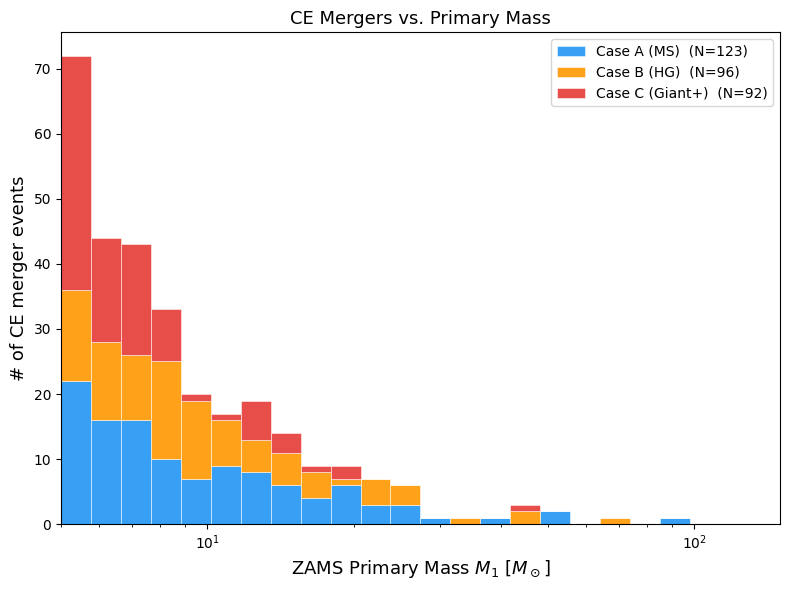

In [27]:
case_colors  = {'Case A (MS)': '#2196F3', 'Case B (HG)': '#FF9800', 'Case C (Giant+)': '#E53935'}
case_masks   = {
    'Case A (MS)': ce_mergers['case_A'],
    'Case B (HG)': ce_mergers['case_B'],
    'Case C (Giant+)': ce_mergers['case_C'],
}

# -- Plotting the distribution of ZAMS primary masses for CE mergers by MT case --
# Create log bins from 5 to 150 Msun
m1_bins = np.logspace(np.log10(5), np.log10(150), 25)
bin_centers = 0.5 * (m1_bins[:-1] + m1_bins[1:])

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

bottoms = np.zeros(len(m1_bins) - 1)
for label, mask in case_masks.items():
    counts, _ = np.histogram(ce_mergers.loc[mask, 'Mass@ZAMS(1)'], bins=m1_bins)
    ax.bar(bin_centers, counts, width=np.diff(m1_bins),
           bottom=bottoms, color=case_colors[label],
           label=f'{label}  (N={mask.sum():,})',
           edgecolor='white', linewidth=0.4, alpha=0.9)
    bottoms += counts

ax.set_xscale('log')
ax.set_xlabel(r'ZAMS Primary Mass $M_{1}$ [$M_\odot$]', fontsize=13)
ax.set_ylabel('# of CE merger events', fontsize=13)
ax.set_title('CE Mergers vs. Primary Mass', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim([5, 150])

plt.tight_layout()
plt.show()

Tristan: We can conclude from this that CE mergers are dominated by lower-mass primaries, and most come from evolved donors (Case C). Further, CE during HG looks to be least common. For super high ZAMS, CE mergers come primarily from Case A.

How about orbital period?

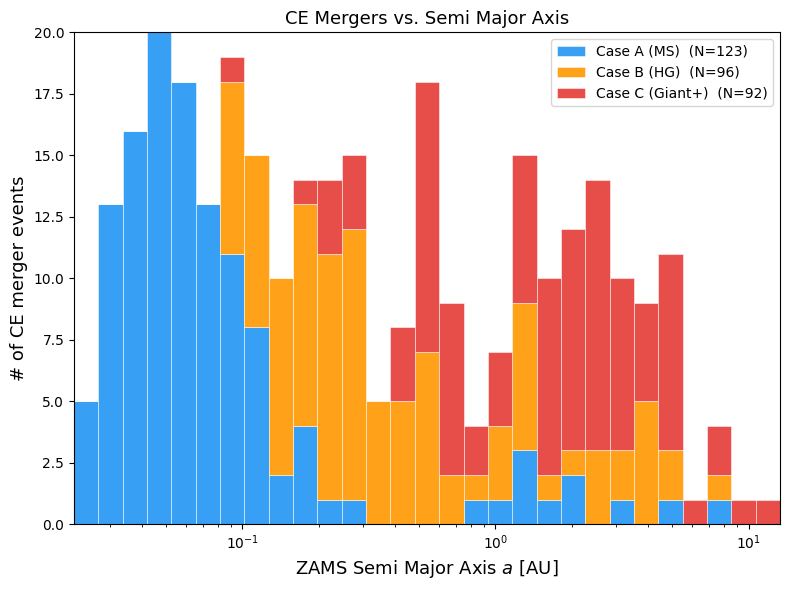

In [28]:
case_colors  = {'Case A (MS)': '#2196F3', 'Case B (HG)': '#FF9800', 'Case C (Giant+)': '#E53935'}
case_masks   = {
    'Case A (MS)': ce_mergers['case_A'],
    'Case B (HG)': ce_mergers['case_B'],
    'Case C (Giant+)': ce_mergers['case_C'],
}

# -- Plotting the distribution of semi-major axes for CE mergers by MT case --
# Create log bins from 5 to 150 Msun
a_data = ce_mergers['SemiMajorAxis@ZAMS']
a_bins = np.logspace(np.log10(a_data.min()), np.log10(a_data.max()), 30)
bin_centers = 0.5 * (a_bins[:-1] + a_bins[1:])

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

bottoms = np.zeros(len(a_bins) - 1)
for label, mask in case_masks.items():
    counts, _ = np.histogram(ce_mergers.loc[mask, 'SemiMajorAxis@ZAMS'], bins=a_bins)
    ax.bar(bin_centers, counts, width=np.diff(a_bins),
           bottom=bottoms, color=case_colors[label],
           label=f'{label}  (N={mask.sum():,})',
           edgecolor='white', linewidth=0.4, alpha=0.9)
    bottoms += counts

ax.set_xscale('log')
ax.set_xlabel(r'ZAMS Semi Major Axis $a$ [AU]', fontsize=13)
ax.set_ylabel('# of CE merger events', fontsize=13)
ax.set_title('CE Mergers vs. Semi Major Axis', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(a_data.min(), a_data.max())

plt.tight_layout()
plt.show()

Think about what you see in the plots. Why does the MT case contribution change over semi-major axis?

Tristan: The same trends are present with higher metallicity.

In [ ]:
# decreased metallicity to 0.0001 (min allowed by COMPAS)

! compas_run_submit compas_testl_config.yaml

python_version = 3
compas_executable_override /Users/tsdevictor/Software/COMPAS/src/COMPAS
grid_filename None
/Users/tsdevictor/Software/COMPAS/src/COMPAS --detailed-output False --number-of-systems 1000 --metallicity 0.0001 --random-seed 42 --mass-transfer-fa 0.5 --common-envelope-alpha 1.0 --mode BSE --logfile-type HDF5 --output-path /Users/tsdevictor/Documents/menon-lab/stellar_mergers/tutorial

COMPAS v03.29.03 (gsl v2.8, boost v1.90.0, HDF5 v2.1.1)
Compact Object Mergers: Population Astrophysics and Statistics
by Team COMPAS (http://compas.science/index.html)
A binary star simulator

Go to https://compas.readthedocs.io/en/latest/index.html for the online documentation
Check https://compas.readthedocs.io/en/latest/pages/whats-new.html to see what's new in the latest release

Start generating binaries at Thu Apr  9 02:03:38 2026

0: Stars merged: (Main_Sequence_>_0.7 -> Early_Asymptotic_Giant_Branch) + (Main_Sequence_<=_0.7 -> Main_Sequence_<=_0.7)
1: Stars merged: (Main_Sequence_>_

In [ ]:
output_path = 'COMPAS_Output_2/COMPAS_Output.h5'
sys_params_df = pd.DataFrame(load_compas_group(output_path, 'BSE_System_Parameters'))
sys_params_df.head(10)

,CH_on_MS(1),CH_on_MS(2),Eccentricity@ZAMS,Equilibrated_At_Birth,Error,Evolution_Status,Mass@ZAMS(1),Mass@ZAMS(2),Merger,Merger_At_Birth,Metallicity@ZAMS(1),Metallicity@ZAMS(2),Omega@ZAMS(1),Omega@ZAMS(2),PO_CE_Alpha,PO_CE_Formalism,PO_LBV_Factor,PO_Sigma_Kick_CCSN_BH,PO_Sigma_Kick_CCSN_NS,PO_Sigma_Kick_ECSN,PO_Sigma_Kick_USSN,PO_WR_Factor,Record_Type,SEED,SN_Kick_Magnitude_Random_Number(1),SN_Kick_Magnitude_Random_Number(2),SemiMajorAxis@ZAMS,Stellar_Type(1),Stellar_Type(2),Stellar_Type@ZAMS(1),Stellar_Type@ZAMS(2),Unbound
0,0,0,0.0,0,43,12,5.416431,0.365624,1,0,0.0001,0.0001,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,42,0.796543,0.950714,1.978083,5,0,1,0,0
1,0,0,0.0,1,43,12,4.427263,4.427263,1,0,0.0001,0.0001,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,43,0.496861,0.609067,0.016798,1,1,1,1,0
2,0,0,0.0,0,43,15,6.263390,2.504365,0,0,0.0001,0.0001,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,44,0.432542,0.104796,25.097195,12,11,1,1,0
3,0,0,0.0,0,43,3,8.209055,0.476427,0,0,0.0001,0.0001,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,45,0.304536,0.549545,39.662997,13,0,1,0,1
4,0,0,0.0,0,43,12,12.963340,0.679756,1,0,0.0001,0.0001,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,46,0.258047,0.634834,0.027398,1,0,1,0,0
5,0,0,0.0,0,43,12,35.560663,23.082648,1,0,0.0001,0.0001,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,47,0.851757,0.974483,0.950272,4,1,1,1,0
6,0,0,0.0,0,43,17,7.327586,6.346153,0,0,0.0001,0.0001,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,48,0.426484,0.891573,2.499422,13,13,1,1,1
7,0,0,0.0,0,43,15,5.141652,2.835602,0,0,0.0001,0.0001,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,49,0.473737,0.247062,49.968815,12,11,1,1,0
8,0,0,0.0,0,43,14,45.432704,18.814374,0,0,0.0001,0.0001,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,50,0.129175,0.228083,105.538949,14,14,1,1,0
9,0,0,0.0,0,43,3,8.613415,1.430632,0,0,0.0001,0.0001,0.0,0.0,1.0,0,1.5,217.0,217.0,30.0,30.0,1.0,1,51,0.327111,0.044712,135.193485,13,11,1,1,1


In [35]:
ce_df = pd.DataFrame(load_compas_group(output_path, 'BSE_Common_Envelopes'))
print(f"Number of CE events: {ce_df.shape[0]}")
print(f"Number of unique binary systems that had a CE event: {ce_df['SEED'].nunique()}")
ce_df.head(10)

Number of CE events: 459
Number of unique binary systems that had a CE event: 445


,BE_Fixed(1),BE_Fixed(2),BE_Kruckow(1),BE_Kruckow(2),BE_Loveridge(1),BE_Loveridge(2),BE_Loveridge_Winds(1),BE_Loveridge_Winds(2),BE_Nanjing(1),BE_Nanjing(2),Binding_Energy<CE(1),Binding_Energy<CE(2),CE_Event_Counter,Double_Core_CE,Eccentricity<CE,Eccentricity>CE,Immediate_RLOF>CE,Lambda@CE(1),Lambda@CE(2),Lambda_Convective(1),Lambda_Convective(2),Lambda_Fixed(1),Lambda_Fixed(2),Lambda_Kruckow(1),Lambda_Kruckow(2),Lambda_Loveridge(1),Lambda_Loveridge(2),Lambda_Loveridge_Winds(1),Lambda_Loveridge_Winds(2),Lambda_Nanjing(1),Lambda_Nanjing(2),Luminosity<CE(1),Luminosity<CE(2),MT_History,Mass(1)<CE,Mass(1)>CE,Mass(2)<CE,Mass(2)>CE,Mass_Convective_Env(1),Mass_Convective_Env(2),Mass_Env(1),Mass_Env(2),Merger,Optimistic_CE,RLOF(1),RLOF(2),Radius(1)<CE,Radius(1)>CE,Radius(2)<CE,Radius(2)>CE,Record_Type,RocheLobe(1)<CE,RocheLobe(1)>CE,RocheLobe(2)<CE,RocheLobe(2)>CE,SEED,SemiMajorAxis<CE,SemiMajorAxis>CE,SemiMajorAxisStage1>CE,Simultaneous_RLOF,Stellar_Type(1),Stellar_Type(1)<CE,Stellar_Type(2),Stellar_Type(2)<CE,Tau_Circ,Tau_Dynamical<CE(1),Tau_Dynamical<CE(2),Tau_Radial<CE(1),Tau_Radial<CE(2),Tau_Sync(1),Tau_Sync(2),Tau_Thermal<CE(1),Tau_Thermal<CE(2),Teff<CE(1),Teff<CE(2),Time,Zeta_Lobe,Zeta_Star
0,0.000000e+00,1.558755e+49,0.000000e+00,3.972445e+46,0.000000e+00,1.558755e+48,0.000000e+00,1.558755e+48,0.000000e+00,1.558755e+48,1.298033e+47,1.558755e+48,1,0,0.0,0.0,0,2.164570,1.000000,0.924362,1.215653,0.1,0.1,0.451222,39.239172,1.0,1.0,1.0,1.0,2.164570,1.000000,2.256241e+04,0.029080,6,5.373059,0.000000,0.365624,0.000000,0.0,0.337908,3.636829,0.000000,1,0,1,0,263.939961,0.000000,0.325469,0.000000,1,260.419858,0.000000,79.124670,0.000000,42,428.566113,0.000000,0.0,0,5,5,0,0,0.0,9.249472e-08,1.535387e-11,0.231929,1.046892e+06,0.0,0.0,1.030347e-04,443.498679,4358.843906,4182.361737,84.368968,26.576573,0.177194
1,4.819119e+50,4.819119e+50,3.466745e+48,3.466745e+48,4.819119e+49,4.819119e+49,4.819119e+49,4.819119e+49,4.819119e+49,4.819119e+49,4.819119e+49,4.819119e+49,1,0,0.0,0.0,0,1.000000,1.000000,0.961403,0.961403,0.1,0.1,13.900989,13.900989,1.0,1.0,1.0,1.0,1.000000,1.000000,4.575773e+02,457.577298,6,4.427263,0.000000,4.427263,0.000000,0.0,0.000000,0.000000,0.000000,1,0,1,1,1.543553,0.000000,1.543553,0.000000,1,1.368724,0.000000,1.368724,0.000000,43,3.612166,0.000000,0.0,1,1,1,1,1,0.0,4.557057e-11,4.557057e-11,-1.000000,-1.000000e+00,0.0,0.0,8.713938e-01,0.871394,21509.629951,21509.629951,0.000000,0.000000,0.000000
2,1.721885e+51,2.899345e+49,2.218906e+49,1.116837e+47,1.721885e+50,2.899345e+48,1.721885e+50,2.899345e+48,1.721885e+50,2.899345e+48,1.721885e+50,2.899345e+48,1,0,0.0,0.0,0,1.000000,1.000000,1.088921,1.221268,0.1,0.1,7.760062,25.960332,1.0,1.0,1.0,1.0,1.000000,1.000000,1.830055e+04,0.259423,6,12.958030,0.000000,0.679756,0.000000,0.0,0.140497,0.000000,0.000000,1,0,1,0,3.700771,0.000000,0.604818,0.000000,1,3.691756,0.000000,1.006548,0.000000,46,5.893639,0.000000,0.0,0,1,1,0,0,0.0,9.888692e-11,2.852531e-11,26.109305,1.856284e+05,0.0,0.0,7.784867e-02,92.470448,34933.933356,5302.336297,8.412412,35.288612,2.000000
3,-1.025312e+34,3.058216e+51,-1.076965e+33,5.773602e+49,-1.025312e+33,3.058216e+50,-1.025312e+33,3.058216e+50,-2.763577e+33,3.058216e+50,9.061364e+49,3.058216e+50,1,0,0.0,0.0,0,0.371009,1.000000,1.091154,1.260796,0.1,0.1,0.952039,5.296894,1.0,1.0,1.0,1.0,0.371009,1.000000,5.343538e+05,106487.137385,6,34.935629,0.000000,22.996087,0.000000,0.0,0.000000,21.837311,0.000000,1,0,1,0,86.120801,0.000000,6.562331,0.000000,1,85.961907,0.000000,71.021670,0.000000,47,206.849006,0.000000,0.0,0,4,4,1,1,0.0,6.760796e-09,1.752791e-10,0.145303,6.876047e+00,0.0,0.0,5.205476e-04,0.023762,16833.744272,40744.854556,6.046913,0.862137,0.273777
4,0.000000e+00,5.773889e+51,0.000000e+00,3.514881e+49,0.000000e+00,5.773889e+50,0.000000e+00,5.773889e+50,0.000000e+00,1.907568e+51,0.000000e+00,5.115234e+49,1,0,0.0,0.0,0,1.000000,0.087880,1.107026,1.097904,0.1,0.1,12150.511392,16.426985,1.0,1.0,1.0,1.0,1.000000,0.302683,1.000000e-10,545544.927521,4,14.0874

In [36]:
# Tristan visualization

rlof_df = pd.DataFrame(load_compas_group(output_path, 'BSE_RLOF'))
print(f"Number of RLOF events: {rlof_df.shape[0]}")
print(f"Number of unique binary systems that had a RLOF event: {rlof_df['SEED'].nunique()}")
rlof_df.head(10)

Number of RLOF events: 1991
Number of unique binary systems that had a RLOF event: 518


,Beta,CEE>MT,Eccentricity<MT,Eccentricity>MT,MT_Event_Counter,Mass(1)<MT,Mass(1)>MT,Mass(2)<MT,Mass(2)>MT,MassTransferRateDonor,MassTransferTimescale,Merger,RLOF(1)<MT,RLOF(1)>MT,RLOF(2)<MT,RLOF(2)>MT,Radius(1)<MT,Radius(1)>MT,Radius(1)|RL<step,Radius(1)|RL>step,Radius(2)<MT,Radius(2)>MT,Radius(2)|RL<step,Radius(2)|RL>step,Record_Type,SEED,SemiMajorAxis<MT,SemiMajorAxis>MT,Stellar_Type(1)<MT,Stellar_Type(1)>MT,Stellar_Type(2)<MT,Stellar_Type(2)>MT,Time<MT,Time>MT,Zeta_Hurley(1),Zeta_Hurley(2),Zeta_Hurley_He(1),Zeta_Hurley_He(2),Zeta_Soberman(1),Zeta_Soberman(2),Zeta_Soberman_He(1),Zeta_Soberman_He(2)
0,2.335625e-07,1,0.0,0.0,1,5.373059,1.736230,0.365624,0.365624,1.797693e+308,3,1,0,1,0,0,263.939961,263.939961,1.013517,58.778850,0.325469,0.325469,0.004113,0.146552,1,42,428.566113,8.697129,5,5,0,0,84.365426,84.368968,0.000000,-0.146427,0.000000,-0.146427,0.000000,-0.333333,0.000000,-0.333333
1,5.000000e-01,1,0.0,0.0,1,4.427263,4.427263,4.427263,4.427263,1.797693e+308,3,1,0,1,0,1,1.543553,1.543553,1.127731,1.127731,1.543553,1.543553,1.127731,1.127731,1,43,3.612166,3.612166,1,1,1,1,0.000000,0.000000,-0.146427,-0.146427,-0.146427,-0.146427,-0.333333,-0.333333,-0.333333,-0.333333
2,4.416338e-04,1,0.0,0.0,1,12.958030,12.958030,0.679756,0.679756,1.797693e+308,3,1,0,1,0,0,3.700771,3.700771,1.002442,1.002442,0.604818,0.604818,0.600883,0.600883,1,46,5.893639,5.893639,1,1,0,0,8.240680,8.412412,-0.146427,-0.146427,-0.146427,-0.146427,-0.333333,-0.333333,-0.333333,-0.333333
3,2.306922e-01,1,0.0,0.0,1,34.935629,13.098318,22.996087,22.996087,1.797693e+308,3,1,0,1,0,0,86.120801,86.120801,1.001848,44.551830,6.562331,6.562331,0.092399,2.625986,1,47,206.849006,5.833175,4,4,1,1,6.045850,6.046913,0.000000,-0.146427,0.000000,-0.146427,0.000000,-0.333333,0.000000,-0.333333
4,3.388092e-02,0,0.0,0.0,1,7.304407,2.433651,6.345859,6.510885,1.591223e+04,2,0,0,1,0,0,213.237268,0.997742,1.012565,0.002075,3.356451,3.301254,0.016996,0.004389,1,48,538.380308,1614.534900,5,8,1,1,47.400239,47.405415,-0.038966,-0.146427,0.000000,-0.146427,0.753367,-0.333333,0.000000,-0.333333
5,2.433879e-02,0,0.0,0.0,1,7.865115,2.644407,6.543159,6.670225,2.043424e+04,2,0,0,1,0,0,239.044617,1.007052,1.012316,0.001987,3.134884,3.115638,0.014440,0.004035,1,53,597.890734,1676.119368,5,8,1,1,41.571682,41.576268,-0.028113,-0.146427,0.000000,-0.146427,0.793083,-0.333333,0.000000,-0.333333
6,2.994121e-02,0,0.0,0.0,1,6.156407,2.009419,4.960472,5.084638,6.243089e+03,2,0,0,1,0,0,143.393798,0.594187,1.004898,0.001957,2.426466,2.423730,0.018768,0.005233,1,54,358.753153,1004.807589,5,8,1,1,65.021825,65.030125,-0.075310,-0.146427,0.000000,-0.146427,0.608351,-0.333333,0.000000,-0.333333
7,3.824062e-01,0,0.0,0.0,1,8.808418,1.852557,7.612150,10.272114,1.939437e+03,2,0,0,1,0,0,31.021713,0.318137,1.018433,0.002900,3.407779,3.405030,0.119591,0.014337,1,55,77.780292,448.434880,2,7,1,1,31.134436,31.137357,-0.146427,-0.146427,0.000000,-0.146427,-0.333333,-0.333333,0.000000,-0.333333
8,4.405039e-02,0,0.0,0.0,2,1.851795,1.179496,10.270089,10.299704,4.281258e+04,2,0,0,1,0,0,113.133648,0.005804,1.031007,0.000026,4.416083,4.408776,0.018587,0.007611,1,55,448.599801,1020.989817,8,11,1,1,37.039546,37.040337,0.000000,-0.146427,0.000000,-0.146427,0.000000,-0.333333,0.000000,-0.333333
9,2.232416e-01,0,0.0,0.0,1,36.264612,14.099410,29.639097,34.587292,1.235099e+05,2,0,0,1,0,0,236.292583,1.255393,1.004961,0.003252,10.854213,9.295700,0.050620,0.016003,1,57,592.999644,1267.733304,4,7,1,1,5.957814,5.958844,-0.146427,-0.146427,0.000000,-0.146427,-0.333333,-0.333333,0.000000,-0.333333


In [37]:
# Tristan visualization

sup_df = pd.DataFrame(load_compas_group(output_path, 'BSE_Supernovae'))
print(f"Number of supernovae: {sup_df.shape[0]}")
print(f"Number of unique binary systems that had a RLOF event: {sup_df['SEED'].nunique()}")
sup_df.head(10)

Number of supernovae: 611
Number of unique binary systems that had a RLOF event: 433


,Applied_Kick_Magnitude(SN),ComponentSpeed(CP),ComponentSpeed(SN),Drawn_Kick_Magnitude(SN),Eccentricity,Eccentricity<SN,Experienced_RLOF(SN),Fallback_Fraction(SN),Is_Hydrogen_Poor(SN),MT_Donor_Hist(SN),Mass(CP),Mass(SN),Mass_CO_Core@CO(SN),Mass_Core@CO(SN),Mass_He_Core@CO(SN),Mass_Total@CO(SN),Orb_Velocity<SN,Orbital_AM_Vector>SN_X,Orbital_AM_Vector>SN_Y,Orbital_AM_Vector>SN_Z,Radius_Core@CO(SN),Radius_Total@CO(SN),Record_Type,SEED,SN_Kick_Mean_Anomaly(SN),SN_Kick_Phi(SN),SN_Kick_Theta(SN),SN_Orbit_Inclination_Angle,SN_Type(SN),SemiMajorAxis,SemiMajorAxis<SN,Stellar_Type(CP),Stellar_Type(SN),Stellar_Type_Prev(SN),Supernova_State,SystemicSpeed,SystemicVelocityX,SystemicVelocityY,SystemicVelocityZ,Time,Unbound
0,252.163646,12.928432,252.522021,252.163646,1.827498e+03,0.000000e+00,0,0.0,0,b'NA ',0.476427,1.182872,1.788673,2.763940,2.763940,8.099977,13.755377,0.728182,-0.391550,0.562530,68.304074,401.413875,1,45,4.219031,6.014594,-1.007353,0.973353,1,-4.700429,8643.335524,0,13,5,1,178.123272,89.762586,-23.970045,-151.973732,38.929506,1
1,158.472308,9.372421,135.376335,158.472308,1.544724e+01,0.000000e+00,1,0.0,1,b'5 ',6.510883,1.206350,1.534322,1.534322,2.433482,2.433482,32.501797,-0.578325,-0.060067,-0.813592,0.000071,14.796823,1,48,1.674288,0.679914,-0.413752,2.521100,1,-89.517511,1614.566503,1,13,8,1,27.765128,21.380005,14.649370,-9.959603,47.508183,1
2,198.838171,135.376335,204.108239,198.838171,1.544724e+01,1.544724e+01,0,0.0,0,b'NA ',1.206350,1.197632,1.440061,1.440061,1.440061,5.736810,0.000000,-0.578325,-0.060067,-0.813592,0.000071,813.985607,1,48,1.789836,2.038709,1.185436,2.521100,1,-99.833038,-99.833038,13,13,6,2,27.765128,21.380005,14.649370,-9.959603,63.060651,1
3,0.000000,0.000000,0.000000,0.000000,5.551115e-17,0.000000e+00,0,0.0,1,b'NA ',18.790142,17.789036,13.465330,13.465330,17.789036,17.789036,13.228434,0.000000,-0.000000,1.000000,0.000071,1.348428,1,50,0.467322,0.134688,-0.208855,0.000000,1,39860.082114,39860.082114,1,14,8,1,0.000000,0.000000,0.000000,0.000000,5.322703,0
4,0.000000,2.958387,2.958387,0.000000,4.599237e-01,5.551115e-17,0,0.0,0,b'NA ',17.789036,6.981516,5.564177,6.981516,6.981516,18.374079,13.076234,0.000000,0.000000,1.000000,1.131979,781.995610,1,50,1.605190,6.261661,-0.769253,0.000000,1,74673.495005,40329.387641,14,14,5,2,2.958387,2.627281,1.359945,0.000000,11.674188,0
5,271.309080,6.836148,271.543141,271.309080,1.661661e+03,0.000000e+00,0,0.0,0,b'NA ',1.430632,1.246131,1.909143,2.916958,2.916958,8.467600,7.995676,-0.042942,0.741920,0.669112,85.055843,438.639412,1,51,3.199407,3.441815,0.292179,0.837784,1,-6.838910,29523.534383,1,13,5,1,125.624262,-115.721402,-32.656746,36.380616,35.871399,1
6,420.824650,6.629705,420.443151,420.824650,1.578110e+04,0.000000e+00,0,0.0,0,b'NA ',0.514449,1.200772,1.764915,2.730577,2.730577,8.017286,7.028450,0.209606,-0.159959,-0.964613,67.949876,394.802661,1,52,0.918938,5.201502,0.239116,2.874768,1,-1.902694,32933.609484,0,13,5,1,296.094561,135.819170,-253.685864,69.775532,39.662888,1
7,316.510319,9.330313,305.022292,316.510319,4.600078e+01,0.000000e+00,1,0.0,1,b'5 ',6.670223,1.198747,1.694744,1.694744,2.644212,2.644212,32.552298,0.563539,0.389566,-0.728466,0.000071,13.393525,1,53,5.317242,4.865266,-0.300136,2.386876,1,-16.516230,1676.155826,1,13,8,1,50.154476,3.491948,-47.958991,-14.255275,41.667953,1
8,127.623503,305.022292,130.767500,127.623503,4.600078e+01,4.600078e+01,0,0.0,0,b'NA ',1.198747,1.211942,1.440144,1.440144,1.440144,6.350182,0.000000,0.563539,0.389566,-0.728466,0.000071,524.825872,1,53,2.858066,3.366215,0.465049,2.386876,1,-17.244393,-17.244393,13,13,6,2,50.154476,3.491948,-47.958991,-14.255275,59.107153,1
9,39.645906,7.313377,51.250071,39.645906,3.820681e+00,0.000000e+00,1,0.0,1,b'5 ',5.084638,1.260000,1.386163,1.386163,2.009098,2.009098,36.689900,0.000301,-0.019043,0.999819,0.012682,215.248790,1,54,0.015813,1.484593,0.036574,0.019046,2,-355.615320,1004.854267,1,13,9,1,4.798355,0.726518,4.734290,0.287894,65.304245,1


There are far less RLOF events and far more supernovae so far.

In [38]:
ce = ce_df.copy() # copy to avoid modifying original dataframe

# Donor stellar type for CE: take star 1 if RLOF(1)==1, else star 2
donor_type = np.where(
    ce['RLOF(1)'] == 1,
    ce['Stellar_Type(1)<CE'],
    ce['Stellar_Type(2)<CE']
)

ce['donor_type'] = donor_type

# Classify MT case based on donor type
ce['case_A'] = (donor_type == 1)
ce['case_B'] = (donor_type == 2)
ce['case_C'] = (donor_type > 2)

# Keep only CE events that resulted in a merger
ce_mergers = ce[ce['Merger'] == 1].copy()

# Merge in ZAMS primary mass and binary separation from sys_params_df via SEED
ce_mergers = ce_mergers.merge(
    sys_params_df[['SEED', 'Mass@ZAMS(1)', 'Mass@ZAMS(2)', 'SemiMajorAxis@ZAMS']],
    on='SEED', how='left'
)

print(f'Total CE events:          {len(ce):,}')
print(f'CE mergers:               {len(ce_mergers):,}')
print(f'  Case A (MS donor):      {ce_mergers["case_A"].sum():,}')
print(f'  Case B (HG donor):      {ce_mergers["case_B"].sum():,}')
print(f'  Case C (giant+ donor):  {ce_mergers["case_C"].sum():,}')

Total CE events:          459
CE mergers:               349
  Case A (MS donor):      95
  Case B (HG donor):      54
  Case C (giant+ donor):  200


As opposed to, with higher metallicity:

Total CE events:          473 \
CE mergers:               311 \
  Case A (MS donor):      123 \
  Case B (HG donor):      96 \
  Case C (giant+ donor):  92

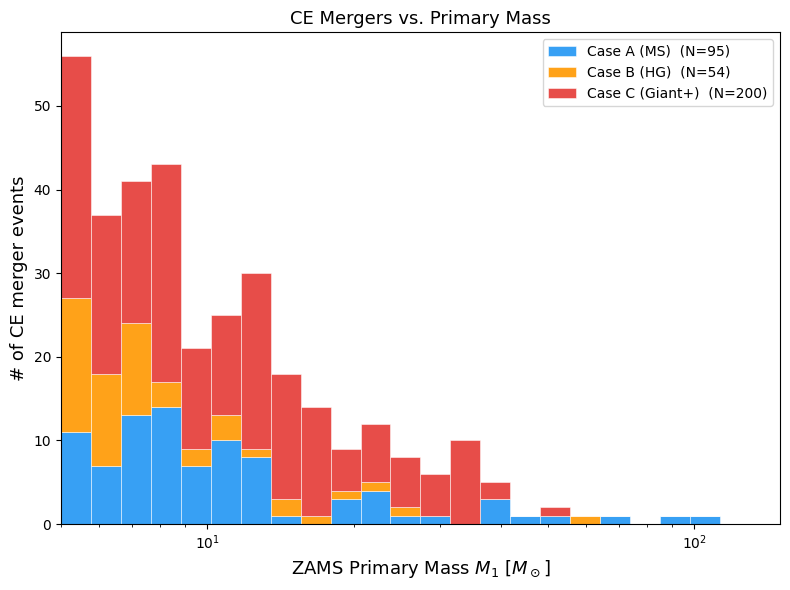

In [39]:
case_colors  = {'Case A (MS)': '#2196F3', 'Case B (HG)': '#FF9800', 'Case C (Giant+)': '#E53935'}
case_masks   = {
    'Case A (MS)': ce_mergers['case_A'],
    'Case B (HG)': ce_mergers['case_B'],
    'Case C (Giant+)': ce_mergers['case_C'],
}

# -- Plotting the distribution of ZAMS primary masses for CE mergers by MT case --
# Create log bins from 5 to 150 Msun
m1_bins = np.logspace(np.log10(5), np.log10(150), 25)
bin_centers = 0.5 * (m1_bins[:-1] + m1_bins[1:])

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

bottoms = np.zeros(len(m1_bins) - 1)
for label, mask in case_masks.items():
    counts, _ = np.histogram(ce_mergers.loc[mask, 'Mass@ZAMS(1)'], bins=m1_bins)
    ax.bar(bin_centers, counts, width=np.diff(m1_bins),
           bottom=bottoms, color=case_colors[label],
           label=f'{label}  (N={mask.sum():,})',
           edgecolor='white', linewidth=0.4, alpha=0.9)
    bottoms += counts

ax.set_xscale('log')
ax.set_xlabel(r'ZAMS Primary Mass $M_{1}$ [$M_\odot$]', fontsize=13)
ax.set_ylabel('# of CE merger events', fontsize=13)
ax.set_title('CE Mergers vs. Primary Mass', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim([5, 150])

plt.tight_layout()
plt.show()

The same trend is apparent, though far more irregular

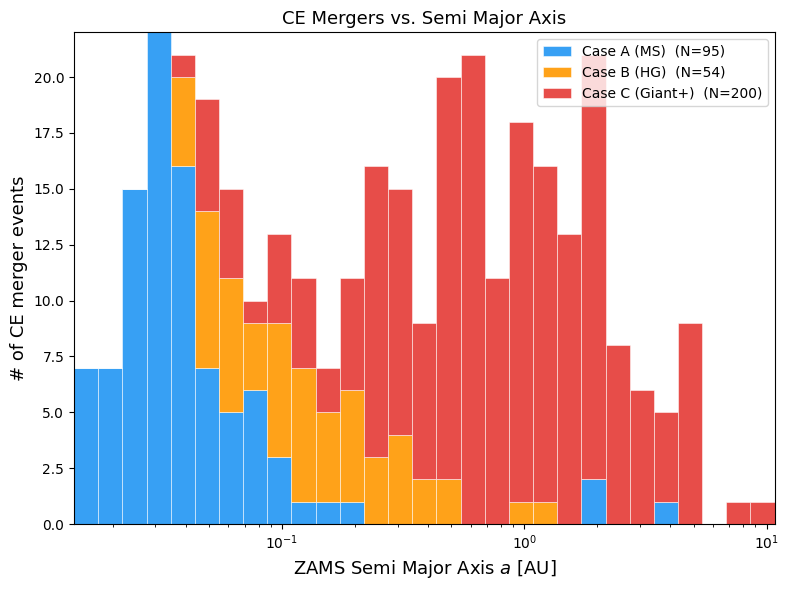

In [40]:
case_colors  = {'Case A (MS)': '#2196F3', 'Case B (HG)': '#FF9800', 'Case C (Giant+)': '#E53935'}
case_masks   = {
    'Case A (MS)': ce_mergers['case_A'],
    'Case B (HG)': ce_mergers['case_B'],
    'Case C (Giant+)': ce_mergers['case_C'],
}

# -- Plotting the distribution of semi-major axes for CE mergers by MT case --
# Create log bins from 5 to 150 Msun
a_data = ce_mergers['SemiMajorAxis@ZAMS']
a_bins = np.logspace(np.log10(a_data.min()), np.log10(a_data.max()), 30)
bin_centers = 0.5 * (a_bins[:-1] + a_bins[1:])

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

bottoms = np.zeros(len(a_bins) - 1)
for label, mask in case_masks.items():
    counts, _ = np.histogram(ce_mergers.loc[mask, 'SemiMajorAxis@ZAMS'], bins=a_bins)
    ax.bar(bin_centers, counts, width=np.diff(a_bins),
           bottom=bottoms, color=case_colors[label],
           label=f'{label}  (N={mask.sum():,})',
           edgecolor='white', linewidth=0.4, alpha=0.9)
    bottoms += counts

ax.set_xscale('log')
ax.set_xlabel(r'ZAMS Semi Major Axis $a$ [AU]', fontsize=13)
ax.set_ylabel('# of CE merger events', fontsize=13)
ax.set_title('CE Mergers vs. Semi Major Axis', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(a_data.min(), a_data.max())

plt.tight_layout()
plt.show()

The same trend is apparent, though again, far more irregular. We also have more of Case C and less of Case B as compared to the previous analyses. Remembering that

Case A: mass transfer during main sequence \
Case B: during Hertzsprung gap (post-MS, pre-giant) \
Case C: during giant phase

This seems to suggest that we have far more MT during the giant phase than the Hertzsprung gap (as opposed to when we had higher metallicity)

TRYING TO DETERMINE WHAT FLAGS SET UP UNSTABLE MASS TRANSFER IN COMPAS

In [72]:
import copy
import itertools
import subprocess
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

In [73]:
# base config
base_config_path = Path("compas_testl_config.yaml")

# where all runs will go
run_root = Path(".")
run_root.mkdir(exist_ok=True)

# use a smaller pilot first so this stays fast
n_systems = 300

# stage 1: parameters that actually control MT stability
qcrit_prescriptions = [
    "NONE",
    "CLAEYS",
    "GE",
    "GE_IC",
    "HURLEY_HJELLMING_WEBBINK",
]

case_bb_values = [
    "ALWAYS_STABLE",
    "TREAT_AS_OTHER_MT",
    "ALWAYS_UNSTABLE",
]

# stage 2: parameters that affect CE / post-instability outcomes
alpha_values = [0.5, 1.0, 2.0]
fa_values = [0.0, 0.5, 1.0]

In [ ]:
def load_yaml(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)

def save_yaml(obj, path):
    with open(path, "w") as f:
        yaml.safe_dump(obj, f, sort_keys=False)

def set_compas_option(cfg, key, value):
    # put the option into the right yaml block based on python type
    if isinstance(value, bool):
        cfg.setdefault("booleanChoices", {})[key] = value
    elif isinstance(value, (int, float)) and not isinstance(value, bool):
        cfg.setdefault("numericalChoices", {})[key] = value
    elif isinstance(value, str):
        cfg.setdefault("stringChoices", {})[key] = value
    else:
        raise TypeError(f"unsupported value type for {key}: {type(value)}")

def find_h5_file(_run_dir=None):
    """
    COMPAS is writing to COMPAS_Output*, COMPAS_Output_1, ...
    in the current working directory, so grab the newest .h5 there.
    """
    h5_files = list(Path(".").glob("COMPAS_Output*/**/*.h5"))
    if not h5_files:
        raise FileNotFoundError("no hdf5 output found in COMPAS_Output* directories")
    return max(h5_files, key=lambda p: p.stat().st_mtime)

def load_group_if_present(h5_path, group_name):
    with h5py.File(h5_path, "r") as f:
        if group_name not in f:
            return pd.DataFrame()
        group = f[group_name]
        data = {col: group[col][:] for col in group.keys()}
    return pd.DataFrame(data)

def summarize_run(h5_path, meta):
    sys_df = load_group_if_present(h5_path, "BSE_System_Parameters")
    rlof_df = load_group_if_present(h5_path, "BSE_RLOF")
    ce_df = load_group_if_present(h5_path, "BSE_Common_Envelopes")

    n_total = int(sys_df["SEED"].nunique()) if "SEED" in sys_df.columns else np.nan
    n_rlof = int(rlof_df["SEED"].nunique()) if "SEED" in rlof_df.columns else 0
    n_ce = int(ce_df["SEED"].nunique()) if "SEED" in ce_df.columns else 0

    if "Merger" in ce_df.columns and "SEED" in ce_df.columns:
        n_ce_merger = int(ce_df.loc[ce_df["Merger"] == 1, "SEED"].nunique())
    else:
        n_ce_merger = 0

    summary = dict(meta)
    summary.update({
        "n_total_systems": n_total,
        "n_rlof_systems": n_rlof,
        "n_ce_systems": n_ce,
        "n_ce_merger_systems": n_ce_merger,
        "rlof_fraction": n_rlof / n_total if n_total else np.nan,
        "ce_fraction_of_all": n_ce / n_total if n_total else np.nan,
        "ce_merger_fraction_of_all": n_ce_merger / n_total if n_total else np.nan,
        "unstable_fraction_proxy": n_ce / n_rlof if n_rlof else np.nan,
        "h5_path": str(h5_path),
    })
    return summary

def run_compas_case(
    run_name,
    qcrit,
    case_bb="ALWAYS_STABLE",
    alpha=1.0,
    fa=0.5,
    mt_efficiency="THERMAL",
    seed=42,
    n_systems=300,
):
    run_dir = run_root / run_name
    run_dir.mkdir(exist_ok=True)

    cfg = load_yaml(base_config_path)

    # make the run self-contained and reproducible
    set_compas_option(cfg, "--number-of-systems", int(n_systems))
    set_compas_option(cfg, "--random-seed", int(seed))
    set_compas_option(cfg, "--critical-mass-ratio-prescription", qcrit)
    set_compas_option(cfg, "--case-BB-stability-prescription", case_bb)
    set_compas_option(cfg, "--common-envelope-alpha", float(alpha))
    set_compas_option(cfg, "--mass-transfer-accretion-efficiency-prescription", mt_efficiency)
    set_compas_option(cfg, "--mass-transfer-fa", float(fa))
    set_compas_option(cfg, "--output-path", str(run_dir))
    set_compas_option(cfg, "--logfile-type", "HDF5")

    cfg_path = run_dir / "config.yaml"
    save_yaml(cfg, cfg_path)

    proc = subprocess.run(
        ["compas_run_submit", str(cfg_path)],
        capture_output=True,
        text=True,
    )

    if proc.returncode != 0:
        return {
            "run_name": run_name,
            "status": "failed",
            "stderr": proc.stderr,
            "stdout": proc.stdout,
            "qcrit": qcrit,
            "case_bb": case_bb,
            "alpha": alpha,
            "fa": fa,
            "mt_efficiency": mt_efficiency,
        }

    try:
        h5_path = find_h5_file()
        summary = summarize_run(
            h5_path,
            meta={
                "run_name": run_name,
                "status": "ok",
                "qcrit": qcrit,
                "case_bb": case_bb,
                "alpha": alpha,
                "fa": fa,
                "mt_efficiency": mt_efficiency,
            },
        )
        return summary
    except Exception as e:
        return {
            "run_name": run_name,
            "status": "failed_after_run",
            "stderr": str(e),
            "stdout": proc.stdout,
            "qcrit": qcrit,
            "case_bb": case_bb,
            "alpha": alpha,
            "fa": fa,
            "mt_efficiency": mt_efficiency,
        }

In [75]:
test_result = run_compas_case(
    run_name="debug_single_run",
    qcrit="NONE",
    case_bb="ALWAYS_STABLE",
    alpha=1.0,
    fa=0.5,
    mt_efficiency="THERMAL",
    seed=101,
    n_systems=100,
)

test_result

{'run_name': 'debug_single_run',
 'status': 'ok',
 'qcrit': 'NONE',
 'case_bb': 'ALWAYS_STABLE',
 'alpha': 1.0,
 'fa': 0.5,
 'mt_efficiency': 'THERMAL',
 'n_total_systems': 100,
 'n_rlof_systems': 50,
 'n_ce_systems': 45,
 'n_ce_merger_systems': 37,
 'rlof_fraction': 0.5,
 'ce_fraction_of_all': 0.45,
 'ce_merger_fraction_of_all': 0.37,
 'unstable_fraction_proxy': 0.9,
 'h5_path': 'COMPAS_Output/COMPAS_Output.h5'}

In [76]:
# stage 1: what settings change unstable MT?
# here we vary the actual stability prescriptions and keep alpha/fa at baseline

stage1_results = []

for i, (qcrit, case_bb) in enumerate(itertools.product(qcrit_prescriptions, case_bb_values)):
    run_name = f"stage1__qcrit_{qcrit}__casebb_{case_bb}"
    result = run_compas_case(
        run_name=run_name,
        qcrit=qcrit,
        case_bb=case_bb,
        alpha=1.0,
        fa=0.5,
        mt_efficiency="THERMAL",
        seed=100 + i,
        n_systems=n_systems,
    )
    stage1_results.append(result)
    print(f"{run_name}: {result['status']}")

stage1_df = pd.DataFrame(stage1_results)
stage1_df

stage1__qcrit_NONE__casebb_ALWAYS_STABLE: ok
stage1__qcrit_NONE__casebb_TREAT_AS_OTHER_MT: ok
stage1__qcrit_NONE__casebb_ALWAYS_UNSTABLE: ok
stage1__qcrit_CLAEYS__casebb_ALWAYS_STABLE: ok
stage1__qcrit_CLAEYS__casebb_TREAT_AS_OTHER_MT: ok
stage1__qcrit_CLAEYS__casebb_ALWAYS_UNSTABLE: ok
stage1__qcrit_GE__casebb_ALWAYS_STABLE: ok
stage1__qcrit_GE__casebb_TREAT_AS_OTHER_MT: ok
stage1__qcrit_GE__casebb_ALWAYS_UNSTABLE: ok
stage1__qcrit_GE_IC__casebb_ALWAYS_STABLE: ok
stage1__qcrit_GE_IC__casebb_TREAT_AS_OTHER_MT: ok
stage1__qcrit_GE_IC__casebb_ALWAYS_UNSTABLE: ok
stage1__qcrit_HURLEY_HJELLMING_WEBBINK__casebb_ALWAYS_STABLE: ok
stage1__qcrit_HURLEY_HJELLMING_WEBBINK__casebb_TREAT_AS_OTHER_MT: ok
stage1__qcrit_HURLEY_HJELLMING_WEBBINK__casebb_ALWAYS_UNSTABLE: ok


,run_name,status,qcrit,case_bb,alpha,fa,mt_efficiency,n_total_systems,n_rlof_systems,n_ce_systems,n_ce_merger_systems,rlof_fraction,ce_fraction_of_all,ce_merger_fraction_of_all,unstable_fraction_proxy,h5_path
0,stage1__qcrit_NONE__casebb_ALWAYS_STABLE,ok,NONE,ALWAYS_STABLE,1.0,0.5,THERMAL,300,155,137,109,0.516667,0.456667,0.363333,0.883871,COMPAS_Output/COMPAS_Output.h5
1,stage1__qcrit_NONE__casebb_TREAT_AS_OTHER_MT,ok,NONE,TREAT_AS_OTHER_MT,1.0,0.5,THERMAL,300,154,136,108,0.513333,0.453333,0.360000,0.883117,COMPAS_Output_1/COMPAS_Output.h5
2,stage1__qcrit_NONE__casebb_ALWAYS_UNSTABLE,ok,NONE,ALWAYS_UNSTABLE,1.0,0.5,THERMAL,300,154,141,129,0.513333,0.470000,0.430000,0.915584,COMPAS_Output_2/COMPAS_Output.h5
3,stage1__qcrit_CLAEYS__casebb_ALWAYS_STABLE,ok,CLAEYS,ALWAYS_STABLE,1.0,0.5,THERMAL,300,154,144,113,0.513333,0.480000,0.376667,0.935065,COMPAS_Output_3/COMPAS_Output.h5
4,stage1__qcrit_CLAEYS__casebb_TREAT_AS_OTHER_MT,ok,CLAEYS,TREAT_AS_OTHER_MT,1.0,0.5,THERMAL,300,153,143,112,0.510000,0.476667,0.373333,0.934641,COMPAS_Output_4/COMPAS_Output.h5
5,stage1__qcrit_CLAEYS__casebb_ALWAYS_UNSTABLE,ok,CLAEYS,ALWAYS_UNSTABLE,1.0,0.5,THERMAL,300,153,146,133,0.510000,0.486667,0.443333,0.954248,COMPAS_Output_5/COMPAS_Output.h5
6,stage1__qcrit_GE__casebb_ALWAYS_STABLE,ok,GE,ALWAYS_STABLE,1.0,0.5,THERMAL,300,154,93,77,0.513333,0.310000,0.256667,0.603896,COMPAS_Output_6/COMPAS_Output.h5
7,stage1__qcrit_GE__casebb_TREAT_AS_OTHER_MT,ok,GE,TREAT_AS_OTHER_MT,1.0,0.5,THERMAL,300,154,93,77,0.513333,0.310000,0.256667,0.603896,COMPAS_Output_7/COMPAS_Output.h5
8,stage1__qcrit_GE__casebb_ALWAYS_UNSTABLE,ok,GE,ALWAYS_UNSTABLE,1.0,0.5,THERMAL,300,154,103,95,0.513333,0.343333,0.316667,0.668831,COMPAS_Output_8/COMPAS_Output.h5
9,stage1__qcrit_GE_IC__casebb_ALWAYS_STABLE,ok,GE_IC,ALWAYS_STABLE,1.0,0.5,THERMAL,300,154,92,77,0.513333,0.306667,0.256667,0.597403,COMPAS_Output_9/COMPAS_Output.h5


In [77]:
# stage 2: once instability physics is chosen, how do alpha and fa affect outcomes?
# fa only matters if the accretion efficiency prescription is fixed

chosen_qcrit_for_stage2 = "CLAEYS"

stage2_results = []

for i, (alpha, fa) in enumerate(itertools.product(alpha_values, fa_values)):
    run_name = f"stage2__qcrit_{chosen_qcrit_for_stage2}__alpha_{alpha}__fa_{fa}"
    result = run_compas_case(
        run_name=run_name,
        qcrit=chosen_qcrit_for_stage2,
        case_bb="TREAT_AS_OTHER_MT",
        alpha=alpha,
        fa=fa,
        mt_efficiency="FIXED",
        seed=500 + i,
        n_systems=n_systems,
    )
    stage2_results.append(result)
    print(f"{run_name}: {result['status']}")

stage2_df = pd.DataFrame(stage2_results)
stage2_df

stage2__qcrit_CLAEYS__alpha_0.5__fa_0.0: ok
stage2__qcrit_CLAEYS__alpha_0.5__fa_0.5: ok
stage2__qcrit_CLAEYS__alpha_0.5__fa_1.0: ok
stage2__qcrit_CLAEYS__alpha_1.0__fa_0.0: ok
stage2__qcrit_CLAEYS__alpha_1.0__fa_0.5: ok
stage2__qcrit_CLAEYS__alpha_1.0__fa_1.0: ok
stage2__qcrit_CLAEYS__alpha_2.0__fa_0.0: ok
stage2__qcrit_CLAEYS__alpha_2.0__fa_0.5: ok
stage2__qcrit_CLAEYS__alpha_2.0__fa_1.0: ok


,run_name,status,qcrit,case_bb,alpha,fa,mt_efficiency,n_total_systems,n_rlof_systems,n_ce_systems,n_ce_merger_systems,rlof_fraction,ce_fraction_of_all,ce_merger_fraction_of_all,unstable_fraction_proxy,h5_path
0,stage2__qcrit_CLAEYS__alpha_0.5__fa_0.0,ok,CLAEYS,TREAT_AS_OTHER_MT,0.5,0.0,FIXED,300,156,145,123,0.520000,0.483333,0.410000,0.929487,COMPAS_Output_15/COMPAS_Output.h5
1,stage2__qcrit_CLAEYS__alpha_0.5__fa_0.5,ok,CLAEYS,TREAT_AS_OTHER_MT,0.5,0.5,FIXED,300,155,148,122,0.516667,0.493333,0.406667,0.954839,COMPAS_Output_16/COMPAS_Output.h5
2,stage2__qcrit_CLAEYS__alpha_0.5__fa_1.0,ok,CLAEYS,TREAT_AS_OTHER_MT,0.5,1.0,FIXED,300,155,148,123,0.516667,0.493333,0.410000,0.954839,COMPAS_Output_17/COMPAS_Output.h5
3,stage2__qcrit_CLAEYS__alpha_1.0__fa_0.0,ok,CLAEYS,TREAT_AS_OTHER_MT,1.0,0.0,FIXED,300,155,144,110,0.516667,0.480000,0.366667,0.929032,COMPAS_Output_18/COMPAS_Output.h5
4,stage2__qcrit_CLAEYS__alpha_1.0__fa_0.5,ok,CLAEYS,TREAT_AS_OTHER_MT,1.0,0.5,FIXED,300,156,149,116,0.520000,0.496667,0.386667,0.955128,COMPAS_Output_19/COMPAS_Output.h5
5,stage2__qcrit_CLAEYS__alpha_1.0__fa_1.0,ok,CLAEYS,TREAT_AS_OTHER_MT,1.0,1.0,FIXED,300,156,149,115,0.520000,0.496667,0.383333,0.955128,COMPAS_Output_20/COMPAS_Output.h5
6,stage2__qcrit_CLAEYS__alpha_2.0__fa_0.0,ok,CLAEYS,TREAT_AS_OTHER_MT,2.0,0.0,FIXED,300,156,145,92,0.520000,0.483333,0.306667,0.929487,COMPAS_Output_21/COMPAS_Output.h5
7,stage2__qcrit_CLAEYS__alpha_2.0__fa_0.5,ok,CLAEYS,TREAT_AS_OTHER_MT,2.0,0.5,FIXED,300,156,149,101,0.520000,0.496667,0.336667,0.955128,COMPAS_Output_22/COMPAS_Output.h5
8,stage2__qcrit_CLAEYS__alpha_2.0__fa_1.0,ok,CLAEYS,TREAT_AS_OTHER_MT,2.0,1.0,FIXED,300,155,148,101,0.516667,0.493333,0.336667,0.954839,COMPAS_Output_23/COMPAS_Output.h5


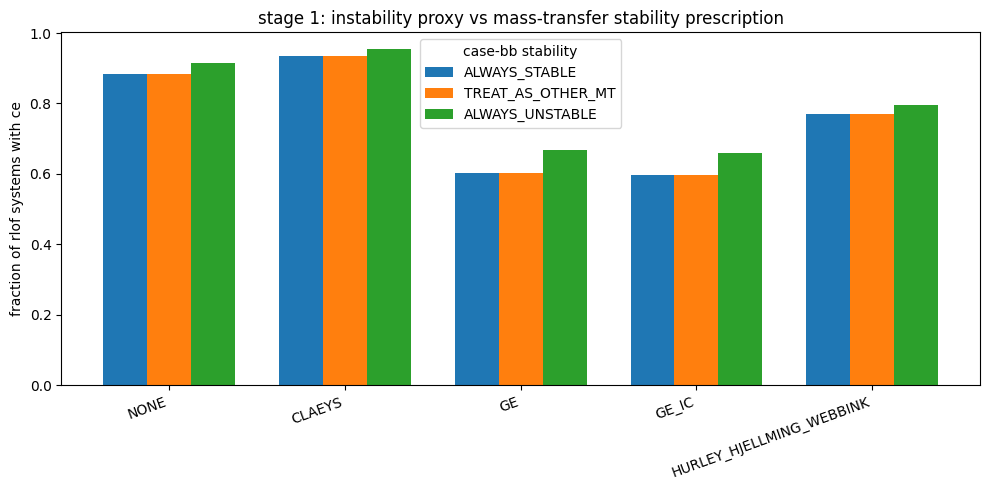

In [80]:
# plot 1: instability proxy vs qcrit prescription
# proxy = fraction of rlof systems that entered common envelope

plot1 = (
    stage1_df
    .groupby(["qcrit", "case_bb"], as_index=False)["unstable_fraction_proxy"]
    .mean()
)

qcrit_order = qcrit_prescriptions
casebb_order = case_bb_values
x = np.arange(len(qcrit_order))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

for j, case_bb in enumerate(casebb_order):
    sub = plot1[plot1["case_bb"] == case_bb].copy()
    y = []
    for q in qcrit_order:
        vals = sub.loc[sub["qcrit"] == q, "unstable_fraction_proxy"].values
        y.append(vals[0] if len(vals) else np.nan)
    ax.bar(x + (j - 1) * width, y, width=width, label=case_bb)

ax.set_xticks(x)
ax.set_xticklabels(qcrit_order, rotation=20, ha="right")
ax.set_ylabel("fraction of rlof systems with ce")
ax.set_title("stage 1: instability proxy vs mass-transfer stability prescription")
ax.legend(title="case-bb stability")
plt.tight_layout()
plt.show()

unstable mass transfer in COMPAS is primarily controlled by

--critical-mass-ratio-prescription \
(secondarily) --case-BB-stability-prescription

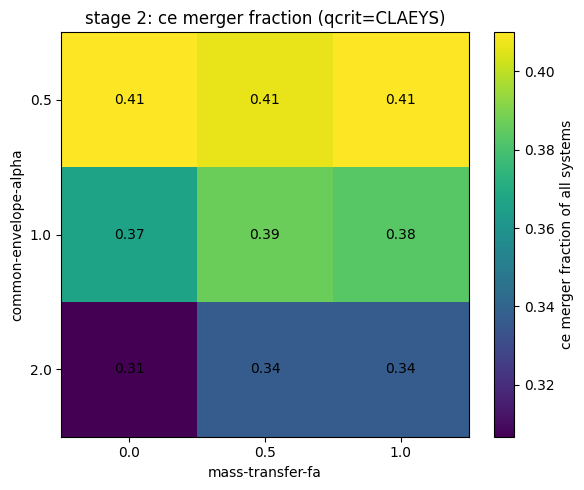

In [81]:
# plot 2: alpha-fa sensitivity for ce merger outcomes
# this is not the primary instability trigger plot; it shows how outcomes shift once ce is in play

heat = (
    stage2_df
    .pivot(index="alpha", columns="fa", values="ce_merger_fraction_of_all")
    .sort_index()
)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(heat.values, aspect="auto")

ax.set_xticks(np.arange(len(heat.columns)))
ax.set_xticklabels([str(c) for c in heat.columns])
ax.set_yticks(np.arange(len(heat.index)))
ax.set_yticklabels([str(i) for i in heat.index])

ax.set_xlabel("mass-transfer-fa")
ax.set_ylabel("common-envelope-alpha")
ax.set_title(f"stage 2: ce merger fraction (qcrit={chosen_qcrit_for_stage2})")

for i in range(len(heat.index)):
    for j in range(len(heat.columns)):
        val = heat.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center")

fig.colorbar(im, ax=ax, label="ce merger fraction of all systems")
plt.tight_layout()
plt.show()

In [82]:
# quick interpretation helper

best_stage1 = stage1_df.sort_values("unstable_fraction_proxy", ascending=False).head(10)
best_stage2 = stage2_df.sort_values("ce_merger_fraction_of_all", ascending=False).head(10)

print("top stage 1 runs by instability proxy")
display(best_stage1[[
    "qcrit", "case_bb", "unstable_fraction_proxy", "n_rlof_systems", "n_ce_systems"
]])

print("top stage 2 runs by ce merger fraction")
display(best_stage2[[
    "alpha", "fa", "ce_merger_fraction_of_all", "unstable_fraction_proxy"
]])

top stage 1 runs by instability proxy


,qcrit,case_bb,unstable_fraction_proxy,n_rlof_systems,n_ce_systems
5,CLAEYS,ALWAYS_UNSTABLE,0.954248,153,146
3,CLAEYS,ALWAYS_STABLE,0.935065,154,144
4,CLAEYS,TREAT_AS_OTHER_MT,0.934641,153,143
2,NONE,ALWAYS_UNSTABLE,0.915584,154,141
0,NONE,ALWAYS_STABLE,0.883871,155,137
1,NONE,TREAT_AS_OTHER_MT,0.883117,154,136
14,HURLEY_HJELLMING_WEBBINK,ALWAYS_UNSTABLE,0.794872,156,124
13,HURLEY_HJELLMING_WEBBINK,TREAT_AS_OTHER_MT,0.770701,157,121
12,HURLEY_HJELLMING_WEBBINK,ALWAYS_STABLE,0.769231,156,120
8,GE,ALWAYS_UNSTABLE,0.668831,154,103


top stage 2 runs by ce merger fraction


,alpha,fa,ce_merger_fraction_of_all,unstable_fraction_proxy
0,0.5,0.0,0.410000,0.929487
2,0.5,1.0,0.410000,0.954839
1,0.5,0.5,0.406667,0.954839
4,1.0,0.5,0.386667,0.955128
5,1.0,1.0,0.383333,0.955128
3,1.0,0.0,0.366667,0.929032
7,2.0,0.5,0.336667,0.955128
8,2.0,1.0,0.336667,0.954839
6,2.0,0.0,0.306667,0.929487
